<a href="https://colab.research.google.com/github/raviradadiya1414/Sonar-rock-VS-Mine-prediction/blob/main/Sonar_rock_VS_Mine_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/sonar data.csv')
df.head()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [ ]:
df.shape

(207, 61)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.

In [ ]:
df['R'].value_counts()

,count
R,
M,111
R,96


In [ ]:
print(df.isnull().sum())

0.0200    0
0.0371    0
0.0428    0
0.0207    0
0.0954    0
         ..
0.0180    0
0.0084    0
0.0090    0
0.0032    0
R         0
Length: 61, dtype: int64


In [ ]:
df.groupby('R').mean()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
R,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022524,0.030232,0.035879,0.041664,0.061680,0.096199,0.113767,0.117153,0.135584,0.158785,...,0.012198,0.010533,0.009673,0.009451,0.008581,0.007333,0.007708,0.006659,0.007058,0.006053


In [ ]:
df.groupby('R').describe()

0.0200                                                               0.0371  \
   count      mean       std     min      25%     50%      75%     max  count   
R                                                                               
M  111.0  0.034989  0.027074  0.0015  0.01795  0.0269  0.04185  0.1371  111.0   
R   96.0  0.022524  0.014762  0.0025  0.01220  0.0201  0.02915  0.0856   96.0   

             ...    0.0090         0.0032                                      \
       mean  ...       75%     max  count      mean       std     min     25%   
R            ...                                                                
M  0.045544  ...  0.011350  0.0364  111.0  0.006930  0.005958  0.0006  0.0031   
R  0.030232  ...  0.008675  0.0294   96.0  0.006053  0.003677  0.0011  0.0030   

                            
       50%     75%     max  
R                           
M  0.00530  0.0092  0.0439  
R  0.00545  0.0078  0.0180  

[2 rows x 480 columns]

<Axes: xlabel='R', ylabel='count'>

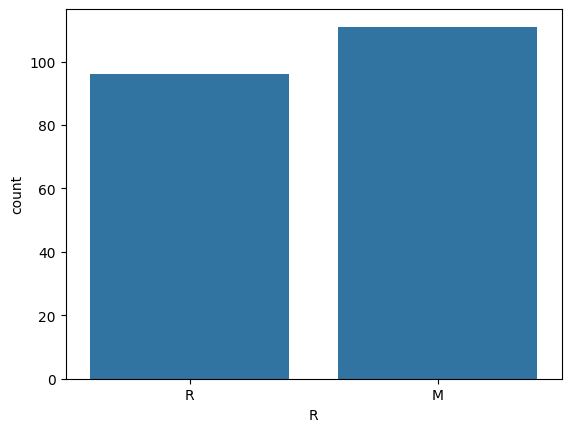

In [ ]:
sns.countplot(data=df, x='R')

In [ ]:
x = df.drop(columns='R',axis=1)
y = df['R']

In [ ]:
label = LabelEncoder()
y = label.fit_transform(y)

In [ ]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
models = ['LogisticRegression','RandomForestClassifier','svm','KNeighborsClassifier','DecisionTreeClassifier']
accuracy = []
recall = []
f1 = []


In [ ]:
model_1 = LogisticRegression()
model_2 = RandomForestClassifier()
model_3 = svm.SVC()
model_4 = KNeighborsClassifier(n_neighbors=25)
model_5 = DecisionTreeClassifier()

In [ ]:
def model(model):
  model.fit(x_train,y_train)
  y_pre = model.predict(x_test)

  accuracy.append(accuracy_score(y_test,y_pre))
  recall.append(recall_score(y_test,y_pre))
  f1.append(f1_score(y_test,y_pre))

  sns.heatmap(confusion_matrix(y_test,y_pre),annot=True)
  plt.show()

  print(model)
  print(f'accuracy:{accuracy_score(y_test,y_pre)}')
  print(f'recall:{recall_score(y_test,y_pre)}')
  print(f'f1:{f1_score(y_test,y_pre)}')

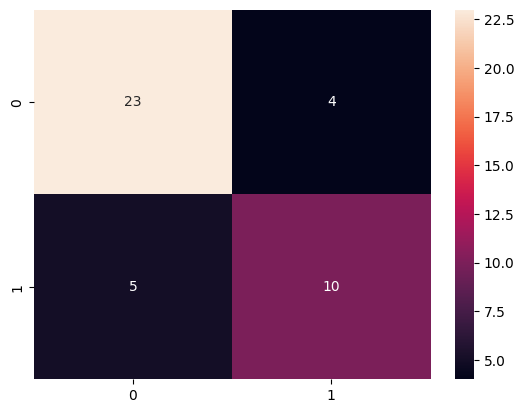

LogisticRegression()
accuracy:0.7857142857142857
recall:0.6666666666666666
f1:0.6896551724137931


In [ ]:
model(model_1)

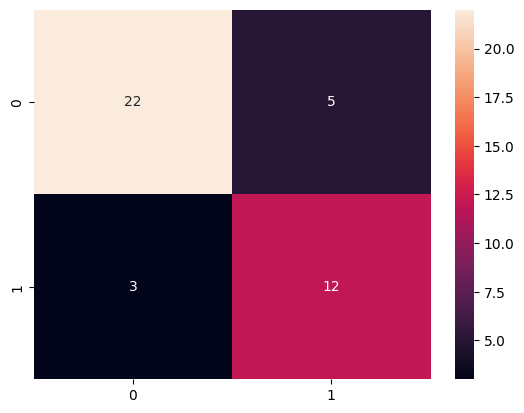

RandomForestClassifier()
accuracy:0.8095238095238095
recall:0.8
f1:0.75


In [ ]:
model(model_2)

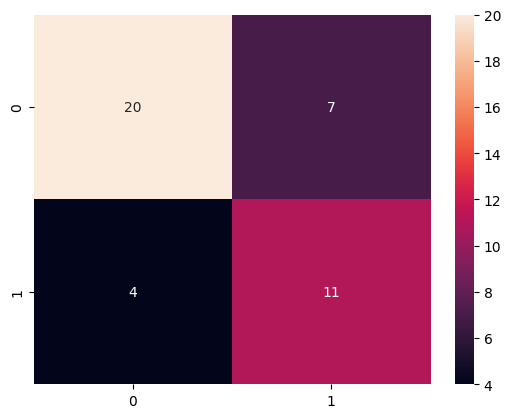

SVC()
accuracy:0.7380952380952381
recall:0.7333333333333333
f1:0.6666666666666666


In [ ]:
model(model_3)

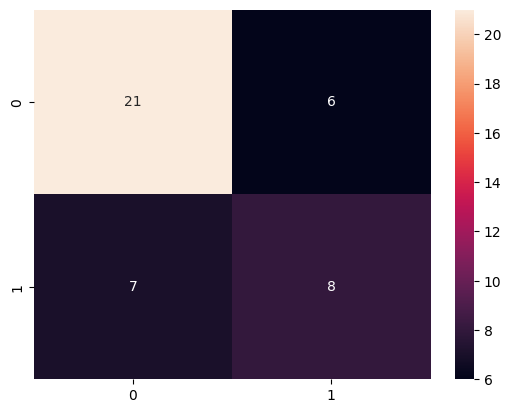

KNeighborsClassifier(n_neighbors=25)
accuracy:0.6904761904761905
recall:0.5333333333333333
f1:0.5517241379310345


In [ ]:
model(model_4)

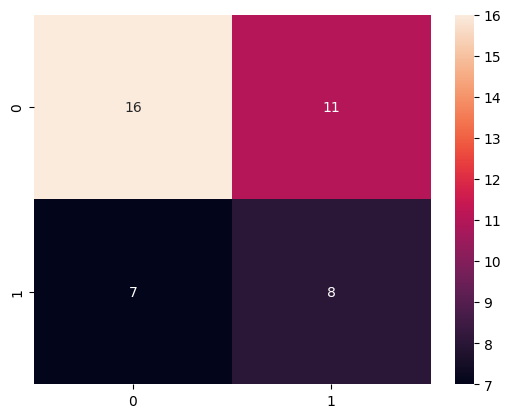

DecisionTreeClassifier()
accuracy:0.5714285714285714
recall:0.5333333333333333
f1:0.47058823529411764


In [ ]:
model(model_5)

In [ ]:
accuracy

[0.7857142857142857,
 0.8095238095238095,
 0.7380952380952381,
 0.6904761904761905,
 0.5714285714285714]

In [ ]:
table = pd.DataFrame(data={'models':models,'accuracy':accuracy,'recall':recall,'f1':f1})
table

,models,accuracy,recall,f1
0,LogisticRegression,0.785714,0.666667,0.689655
1,RandomForestClassifier,0.809524,0.800000,0.750000
2,svm,0.738095,0.733333,0.666667
3,KNeighborsClassifier,0.690476,0.533333,0.551724
4,DecisionTreeClassifier,0.571429,0.533333,0.470588


In [ ]:
table['accuracy'].max()

0.8095238095238095

<Axes: >

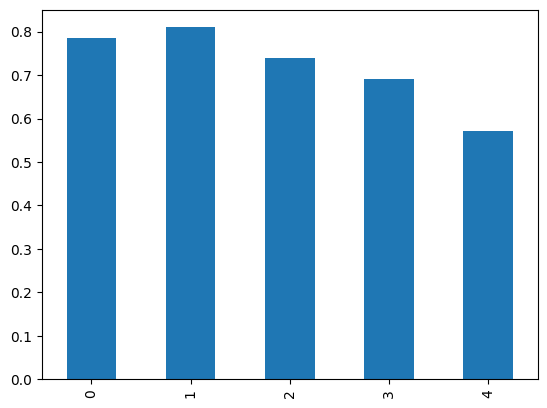

In [ ]:
table['accuracy'].plot(kind='bar')

In [ ]:
label.classes_

array(['M', 'R'], dtype=object)

In [ ]:
def pre(data,model=model_2):
  data = np.array(data).reshape(1,-1)
  data = scaler.transform(data)
  pre = model.predict(data)
  if pre == 0:
    print('Mine')
  else:
    print('Rock')

In [ ]:
data = [0.0238, 0.0451, 0.0617, 0.0885, 0.1324, 0.1498, 0.1759, 0.1632, 0.1280, 0.1047,
0.0739, 0.0581, 0.0904, 0.1176, 0.1439, 0.1550, 0.1387, 0.1223, 0.0978, 0.0756,
0.0524, 0.0369, 0.0612, 0.0898, 0.1185, 0.1472, 0.1641, 0.1713, 0.1586, 0.1308,
0.1053, 0.0804, 0.0542, 0.0331, 0.0475, 0.0698, 0.0962, 0.1217, 0.1465, 0.1668,
0.1774, 0.1592, 0.1329, 0.1098, 0.0825, 0.0599, 0.0436, 0.0571, 0.0794, 0.1018,
0.1276, 0.1491, 0.1648, 0.1729, 0.1604, 0.1359, 0.1093, 0.0837, 0.0615, 0.0462]

In [ ]:
pre(data)

Rock
